<a href="https://colab.research.google.com/github/kmcarranza/Bipartition-Graph/blob/master/UGStudy_Group_Waveform_Tutorial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Waveform Tutorial - UG Study Group 2025

Hello! This tutorial notebook is designed to be used alongside Lucy's "CBC Waveform Modelling" Science Seminar.

It will be a chance for you to generate some waveforms for yourself, to see and investigate the behaviour of these waveform models, their features and their differences.

This tutorial is on waveform generation with `LALSuite`, which is written in C but we will be interacting with using Python. Prerequisite for this tutorial is a basic, working knowledge of Python. First, we will need to install lalsuite, which has all the necessary lalsimulation code we need.


In [ ]:
!pip install lalsuite

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 2.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.4/40.4 MB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 110.5/110.5 kB 4.9 MB/s eta 0:00:00
  Created wheel for ligo-segments: filename=ligo_segments-1.4.0-cp311-cp311-linux_x86_64.whl size=102028 sha256=b515c52acfd10d69ecba5f57f2de82242f019fef7a83bb9eced6ab00d3a9fcbd
  Stored in directory: /root/.cache/pip/wheels/02/2b/93/c2ee2b6f4ea9572ee4f5ade0115c4bd0887be6228328740dae
Successfully built ligo-segments


## Gravitational Waveforms

This tutorial will focus on gravitational waves (GW) generated by Compact Binary Coalescences (CBC), such as coalescing binary black holes (BBH), binary neutron stars (BNS) and neutron star - black holes (NSBH). Any modeled GW generated by a CBC depends on a set of intrinsic parameters, like the masses and spins of the system, and extrinsic parameters, like the sky position and distance to the source.

Mathematically, a GW $h(t)$ can be written as:

$h(t, \vec{\lambda}) = A(t, \vec{\lambda})\, e^{i \psi(t, \vec{\lambda})} $,

where $A$ and $\psi$ are the amplitude and phase of the GW, respectively. A GW $h(t)$ may contain information about both the plus $(h_{+}(t))$ and cross $(h_{\times}(t))$ polarizations. In terms of the polarizations, the waveform strain is defined as

$h(t) = h_{+}(t) - ih_{\times}(t)$.
    
Depending on the configuration of the system, a CBC can be classified as being *non-spinning*, having *aligned spins*, or being *precessing*. We will look at each of these categories in slight detail as we progress through the tutorial. Note that for this tutorial, we will focus solely on BBH systems.


# Generate Time-domain (TD) Waveforms using `LALSimulation`

The goals for this section are to:
* Understand the parameter dictionary used to generate a waveform
* Generate a TD waveform from `LALSimulation` in python
* Develop basic intuition for waveform dependence on certain parameters

To generate a waveform, we first need to import the required modules (along with the modules used for the rest of the tutorial).

In [ ]:
# Import modules
import lalsimulation as lalsim
import lal
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np

#import pygrav as pg
import astropy.units as u

# make a dictionary to store a bunch of things to come
h = dict()

# ignore this jumble of output

/usr/local/lib/python3.11/dist-packages/lalsimulation/lalsimulation.py:8: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal


### Non-spinning BBH
We now define a python dictionary for the parameters of our first binary. Here, we will specify an equal-mass, non-spinning BBH waveform and generate the TD polarizations using the `IMRPhenomTPHM` approximant.

By *non-spinning* we mean that each constituent black hole in the system has zero intrinsic angular momentum, so the orbital angular momentum of the binary constitutes the total angular momentum of the system.

Note that below, the parameters must be specified using SI units. We can write the mass parameters `m1` and `m2` in terms of solar masses, then convert using the built-in `LAL` conversions. This also works when converting the distance from parsecs to meters.

In [ ]:
td_params_nonspinning = {
 'm1': 20*lal.MSUN_SI, # Mass of BH1 in kg
 'm2': 20*lal.MSUN_SI, # Mass of BH2 in kg
 'S1x': 0.0,
 'S1y': 0.0,
 'S1z': 0.0,
 'S2x': 0.0,
 'S2y': 0.0,
 'S2z': 0.0,
 'distance': 1e6*lal.PC_SI, # Distance of 1MPC
 'inclination': 0., # Face-on System
 'phiRef': 0.,
 'longAscNodes': 0.0,
 'eccentricity': 0.0,
 'meanPerAno': 0.0,
 'f_min': 20.0,
 'f_ref': 20.0,
 'deltaT': 1./1024.,
 'approximant': lalsim.IMRPhenomTPHM, # Name of approximant tag in LALSimulation
 'LALparams': None}

To access the waveform generating C-functions written in `LALSimulation`, we use the SWIG-wrapped function `SimInspiralTD` which will return $h_{+}$ and $h_{\times}$ parameterized by the time $t$.

Note the peculiar way in which the data is stored in the timeseries objects, e.g. `hp.data.data`.

In [ ]:
# pass our parameter dictionary into SimInspiralTD
hp, hc = lalsim.SimInspiralTD(**td_params_nonspinning)

# store the output in a dictionary so we can call it later. We'll use 'ns' to denote non-spinning
h['ns'] = dict()
h['ns']['plus'] = hp.data.data
h['ns']['cross'] = hc.data.data

# generate the timeseries for our data from its length, the timestep, and the timeshift
data_length = len(hp.data.data)
dt = hp.deltaT
h['ns']['tshift'] = hp.epoch.gpsSeconds + hp.epoch.gpsNanoSeconds/1e9

h['ns']['t'] = np.arange(data_length) * dt + h['ns']['tshift']

The purpose of the timeshift, `hp.epoch`, is to translate the data so that the strain amplitude peaks at approximately $t=0$.

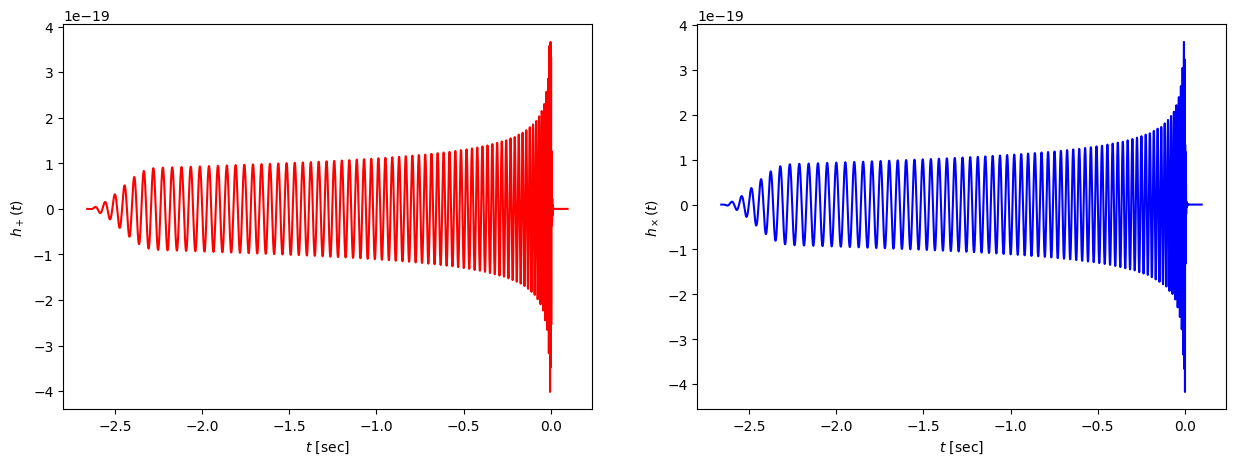

In [ ]:
fig, axs = plt.subplots(1,2,figsize=(15,5))

axs[0].plot(h['ns']['t'], h['ns']['plus'], 'r')
axs[1].plot(h['ns']['t'], h['ns']['cross'], 'b')

for ax, sym in zip(axs,['+','\\times']):
    ax.set_xlabel(r'$t$ [sec]')
    ax.set_ylabel(rf'$h_{sym}(t)$')

plt.show()

In [ ]:
td_params_nonspinning_q1 = {
 'm1': 20*lal.MSUN_SI, # Mass of BH1 in kg
 'm2': 20*lal.MSUN_SI, # Mass of BH2 in kg
 'S1x': 0.0,
 'S1y': 0.0,
 'S1z': 0.0,
 'S2x': 0.0,
 'S2y': 0.0,
 'S2z': 0.0,
 'distance': 1e6*lal.PC_SI, # Distance of 1MPC
 'inclination': 0., # Face-on System
 'phiRef': 0.,
 'longAscNodes': 0.0,
 'eccentricity': 0.0,
 'meanPerAno': 0.0,
 'f_min': 20.0,
 'f_ref': 20.0,
 'deltaT': 1./1024.,
 'approximant': lalsim.IMRPhenomTPHM, # Name of approximant tag in LALSimulation
 'LALparams': None}

td_params_nonspinning_q3 = {
 'm1': 30*lal.MSUN_SI, # Mass of BH1 in kg
 'm2': 10*lal.MSUN_SI, # Mass of BH2 in kg
 'S1x': 0.0,
 'S1y': 0.0,
 'S1z': 0.0,
 'S2x': 0.0,
 'S2y': 0.0,
 'S2z': 0.0,
 'distance': 1e6*lal.PC_SI, # Distance of 1MPC
 'inclination': 0., # Face-on System
 'phiRef': 0.,
 'longAscNodes': 0.0,
 'eccentricity': 0.0,
 'meanPerAno': 0.0,
 'f_min': 20.0,
 'f_ref': 20.0,
 'deltaT': 1./1024.,
 'approximant': lalsim.IMRPhenomTPHM, # Name of approximant tag in LALSimulation
 'LALparams': None}

h_q1 = dict()
h_q3 = dict()

# pass our parameter dictionary into SimInspiralTD
hp_q1, hc_q1 = lalsim.SimInspiralTD(**td_params_nonspinning_q1)
hp_q3, hc_q3 = lalsim.SimInspiralTD(**td_params_nonspinning_q3)

# store the output in a dictionary so we can call it later. We'll use 'ns' to denote non-spinning
h_q1['ns'] = dict()
h_q1['ns']['plus'] = hp_q1.data.data
h_q1['ns']['cross'] = hc_q1.data.data
h_q3['ns'] = dict()
h_q3['ns']['plus'] = hp_q3.data.data
h_q3['ns']['cross'] = hc_q3.data.data

# generate the timeseries for our data from its length, the timestep, and the timeshift
data_length_q1 = len(hp_q1.data.data)
dt_q1 = hp_q1.deltaT
h_q1['ns']['tshift'] = hp_q1.epoch.gpsSeconds + hp_q1.epoch.gpsNanoSeconds/1e9

h_q1['ns']['t'] = np.arange(data_length_q1) * dt_q1 + h_q1['ns']['tshift']

data_length_q3 = len(hp_q3.data.data)
dt_q3 = hp_q3.deltaT
h_q3['ns']['tshift'] = hp_q3.epoch.gpsSeconds + hp_q3.epoch.gpsNanoSeconds/1e9

h_q3['ns']['t'] = np.arange(data_length_q3) * dt_q3 + h_q3['ns']['tshift']

In [ ]:
data_length_q3

3548

In [ ]:
data_length_q1

2824

In [ ]:
dt_q1

0.0009765625

In [ ]:
dt_q3

0.0009765625

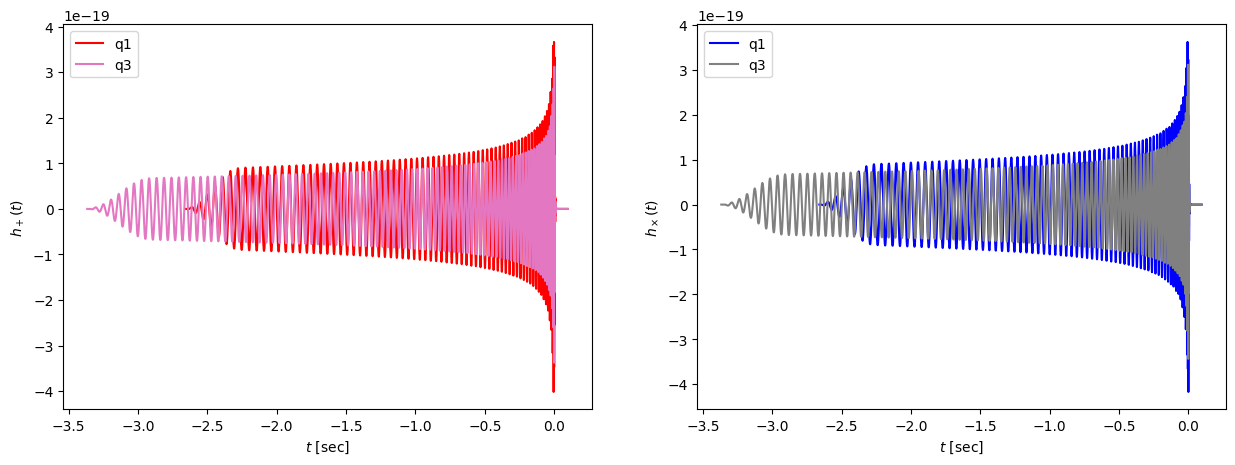

In [ ]:
fig, axs = plt.subplots(1,2,figsize=(15,5))

axs[0].plot(h_q1['ns']['t'], h_q1['ns']['plus'], 'r')
axs[1].plot(h_q1['ns']['t'], h_q1['ns']['cross'], 'b')
axs[0].plot(h_q3['ns']['t'], h_q3['ns']['plus'], 'tab:pink')
axs[1].plot(h_q3['ns']['t'], h_q3['ns']['cross'], 'grey')

for ax, sym in zip(axs,['+','\\times']):
    ax.set_xlabel(r'$t$ [sec]')
    ax.set_ylabel(rf'$h_{sym}(t)$')

axs[0].legend(['q1','q3'])
axs[1].legend(['q1','q3'])
plt.show()

### Aligned-spin BBH
Next, we will generate the waveform polarizations for a BBH with the same masses but with aligned spins, specifying that the black holes each now have some intrinsic angular momentum parallel to the oribtal angular momentum of the binary.

In [ ]:
td_params_alignedspin = {
 'm1': 20*lal.MSUN_SI, # Mass of BH1 in kg
 'm2': 20*lal.MSUN_SI, # Mass of BH2 in kg
 'S1x': 0.0,
 'S1y': 0.0,
 'S1z': 0.5, # some spin aligned with L
 'S2x': 0.0,
 'S2y': 0.0,
 'S2z': 0.2, # some spin aligned with L
 'distance': 1e6*lal.PC_SI, # Distance of 1MPC
 'inclination': 0., # Face-on System
 'phiRef': 0.,
 'longAscNodes': 0.0,
 'eccentricity': 0.0,
 'meanPerAno': 0.0,
 'f_min': 20.0,
 'f_ref': 20.0,
 'deltaT': 1./1024.,
 'approximant': lalsim.IMRPhenomTPHM, # Name of approximant tag in LALSimulation
 'LALparams': None}

In [ ]:
# pass our parameter dictionary into SimInspiralTD
hp, hc = lalsim.SimInspiralTD(**td_params_alignedspin)

h['as'] = dict()
h['as']['plus'] = hp.data.data
h['as']['cross'] = hc.data.data

# generate the timeseries for our data from its length, the timestep, and the timeshift
data_length = len(hp.data.data)
dt = hp.deltaT
h['as']['tshift'] = hp.epoch.gpsSeconds + hp.epoch.gpsNanoSeconds/1e9


h['as']['t'] = np.arange(data_length) * dt + h['as']['tshift']

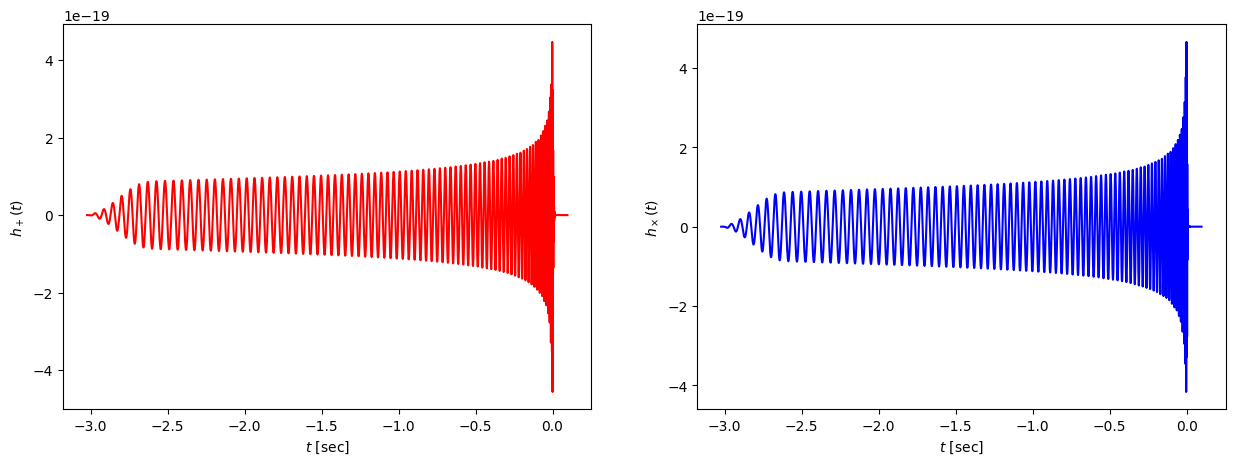

In [ ]:
fig, axs = plt.subplots(1,2,figsize=(15,5))

axs[0].plot(h['as']['t'], h['as']['plus'], 'r')
axs[1].plot(h['as']['t'], h['as']['cross'], 'b')

for ax, sym in zip(axs,['+','\\times']):
    ax.set_xlabel(r'$t$ [sec]')
    ax.set_ylabel(rf'$h_{sym}(t)$')

plt.show()

We know what you're thinking... "those plots dont' look any different!"

The effect of aligned spins can be subtle; let's compare the plus polarizations between the non-spinning and aligned-spin systems to see what's happening. We'll also revert the timeshift to make the effect clearer.

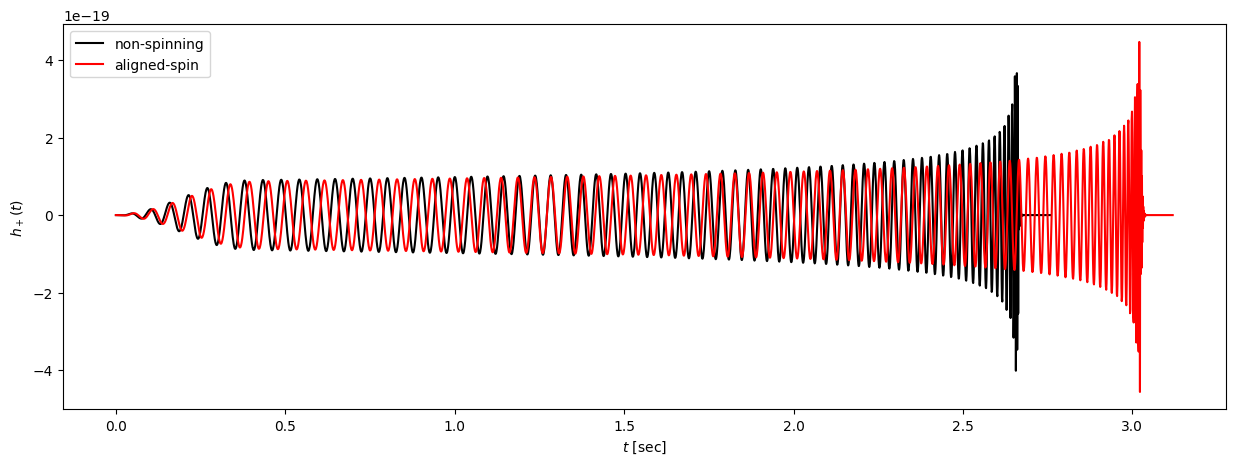

In [ ]:
plt.figure(figsize=(15,5))

plt.plot(h['ns']['t'] - h['ns']['tshift'], h['ns']['plus'], c='k', label='non-spinning')
plt.plot(h['as']['t'] - h['as']['tshift'], h['as']['plus'], c='r', label='aligned-spin')

plt.xlabel(r'$t$ [sec]')
plt.ylabel(r'$h_+(t)$')
plt.legend()

plt.show()

As both of these signals were generated from binary systems with the same total mass and starting frequency (the `f_min` value in the parameter dictionary), we see that they start looking very similar in terms of phase and amplitude. Note however that the system with spinning black holes has a longer duration before merging; this is the "hang-up effect" in action!

### Exercise :
* Generate an `IMRPhenomTPHM` waveform with anit-aligned spins (negative `S1z` and `S2z`), store it in the `h` dictionary as `h['anti_as']` and compare the waveform with the non-spinning waveform. What do you see when the spins are anti-aligned?

### Precessing BBH
Next, we generate the waveform polarizations for a BBH with the same masses but with *precessing* spins. Spin-induced precession for a BBH occurs when the direction of the spins is no longer (anti-)parallel to the orbital angular momentum, causing amplitude modulations to arise in the GW.

In [ ]:
td_params_precessing = {
 'm1': 20*lal.MSUN_SI, # Mass of BH1 in kg
 'm2': 20*lal.MSUN_SI, # Mass of BH2 in kg
 'S1x': 0.8,
 'S1y': 0.1,
 'S1z': 0.0, # note the component of the spins aligned with the orbital angular momentum are set to zero
 'S2x': 0.9,
 'S2y': 0.2,
 'S2z': 0.0, # note the component of the spins aligned with the orbital angular momentum are set to zero
 'distance': 1e6*lal.PC_SI, # Distance of 1MPC
 'inclination': 0., # Face-on System
 'phiRef': 0.,
 'longAscNodes': 0.0,
 'eccentricity': 0.0,
 'meanPerAno': 0.0,
 'f_min': 20.0,
 'f_ref': 20.0,
 'deltaT': 1./1024.,
 'approximant': lalsim.IMRPhenomTPHM, # Name of approximant tag in LALSimulation
 'LALparams': None}

In [ ]:
# pass our parameter dictionary into SimInspiralTD
hp, hc = lalsim.SimInspiralTD(**td_params_precessing)

h['ps'] = dict()
h['ps']['plus'] = hp.data.data
h['ps']['cross'] = hc.data.data

# generate the timeseries for our data from its length, the timestep, and the timeshift
data_length = len(hp.data.data)
dt = hp.deltaT
h['ps']['tshift'] = hp.epoch.gpsSeconds + hp.epoch.gpsNanoSeconds/1e9


h['ps']['t'] = np.arange(data_length) * dt + h['ps']['tshift']

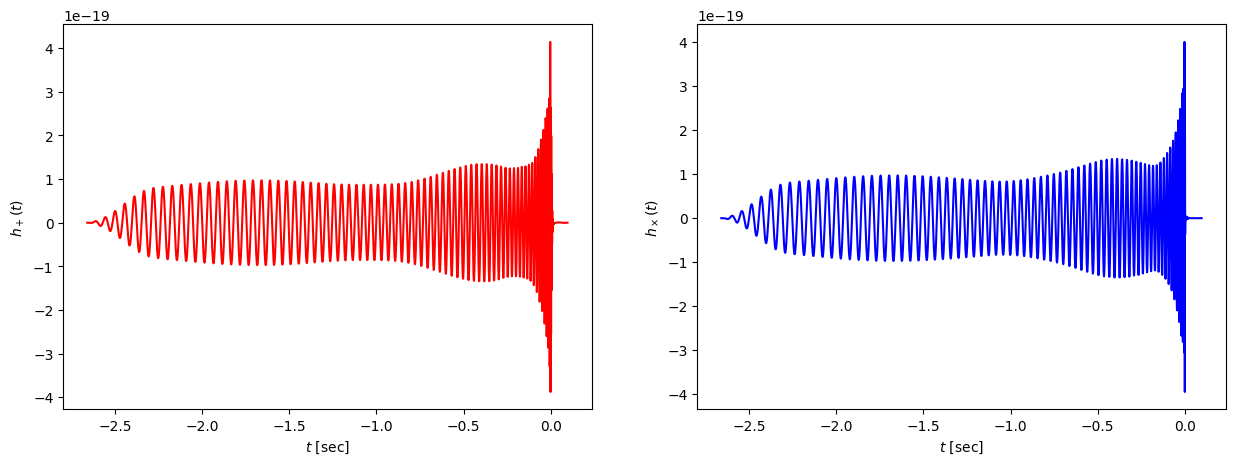

In [ ]:
fig, axs = plt.subplots(1,2,figsize=(15,5))

axs[0].plot(h['ps']['t'], h['ps']['plus'], 'r')
axs[1].plot(h['ps']['t'], h['ps']['cross'], 'b')

for ax, sym in zip(axs,['+','\\times']):
    ax.set_xlabel(r'$t$ [sec]')
    ax.set_ylabel(rf'$h_{sym}(t)$')

plt.show()

Again, let's just briefly compare with the non-spinning waveform.

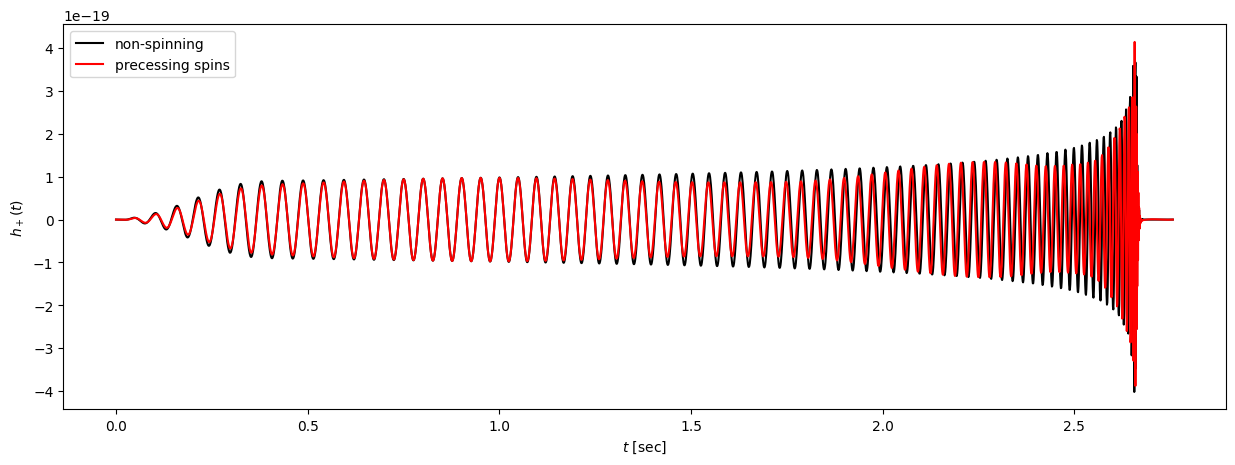

In [ ]:
plt.figure(figsize=(15,5))

plt.plot(h['ns']['t'] - h['ns']['tshift'], h['ns']['plus'], 'k', label='non-spinning')
plt.plot(h['ps']['t'] - h['ps']['tshift'], h['ps']['plus'], 'r', label='precessing spins')

plt.xlabel(r'$t$ [sec]')
plt.ylabel(r'$h_+(t)$')
plt.legend()

plt.show()

In this case, the black holes in the precessing system have no spin in the direction of the orbital angular momentum, so the phase evolution and duration of the precessing signal is roughly equal to that of the non-spinning signal. We do see amplitude modulations in the precessing signal, making the amplitude no longer a purely monotonic function!

### Impact of Inclination

To finish our introduction to TD waveforms, we'll look at how the various signals produced above are modified by changing the `inclination` value in the parameter dictionary. The inclination determines the angle between the binary's orbital angular momentum and the line-of-sight vector to a distant observer (specified at the reference frequency value `f_ref`). Currently all of the signals have been generated with an inclination value of zero (a so-called "face on" view).

We first vary inclination for the non-spinning signal.

In [ ]:
# let's choose an inclination of 90 degrees, an "edge on" view placing the observer in the binary's orbital plane
inclination = np.pi / 2.0

# we can modify the parameter dictionary, rather than having to make a new one
td_params_nonspinning['inclination'] = inclination

# pass our parameter dictionary into SimInspiralTD
hp, hc = lalsim.SimInspiralTD(**td_params_nonspinning)

h['ns-inclined'] = dict()
h['ns-inclined']['plus'] = hp.data.data
h['ns-inclined']['cross'] = hc.data.data

# generate the timeseries for our data from its length, the timestep, and the timeshift
data_length = len(hp.data.data)
dt = hp.deltaT
h['ns-inclined']['tshift'] = hp.epoch.gpsSeconds + hp.epoch.gpsNanoSeconds/1e9

h['ns-inclined']['t'] = np.arange(data_length) * dt + h['ns-inclined']['tshift']

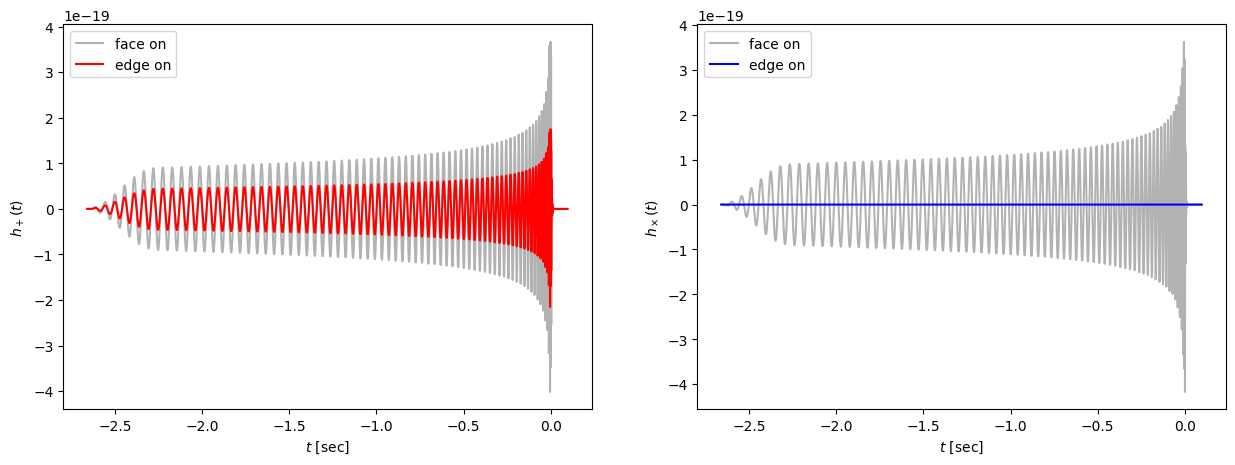

In [ ]:
fig, axs = plt.subplots(1,2,figsize=(15,5))

axs[0].plot(h['ns']['t'], h['ns']['plus'], 'k', alpha=0.3, label='face on')
axs[1].plot(h['ns']['t'], h['ns']['cross'], 'k', alpha=0.3, label='face on')

axs[0].plot(h['ns-inclined']['t'], h['ns-inclined']['plus'], 'r', label='edge on')
axs[1].plot(h['ns-inclined']['t'], h['ns-inclined']['cross'], 'b', label='edge on')

for ax, sym in zip(axs,['+','\\times']):
    ax.set_xlabel(r'$t$ [sec]')
    ax.set_ylabel(rf'$h_{sym}(t)$')
    ax.legend()

plt.show()

Here we see the amplitude of the plus polarization reduced by a factor of two, and the cross polarization is entirely eliminated.

### Exercise:

* Generate a waveform using the precessing parameters specified above at an inclination of 90 degrees, and plot the plus and cross polarizations for both inclinations.
* How does this signal compare to the non-spinning waveform?

# Generate Frequency-domain (FD) Waveforms using LALSimulation

The goal for this section is to:
* Generate FD waveforms from `LALSimulation` in python

Let us now generate frequency-domain waveforms for the same precessing system as above.

In [ ]:
fd_params_precessing = {
 'm1': 20*lal.MSUN_SI, # Mass of BH1 in kg
 'm2': 20*lal.MSUN_SI, # Mass of BH2 in kg
 'S1x': 0.8,
 'S1y': 0.1,
 'S1z': 0.0,
 'S2x': 0.6,
 'S2y': 0.3,
 'S2z': 0.0,
 'distance': 1e6*lal.PC_SI, # Distance of 1MPC
 'inclination': 0., # Face-on System
 'phiRef': 0.,
 'longAscNodes': 0.0,
 'eccentricity': 0.0,
 'meanPerAno': 0.0,
 'f_min': 20.0,
 'f_ref': 20.0,
 'f_max': 2048.0,
 'deltaF': 1./1024.,
 'approximant': lalsim.IMRPhenomXPHM, # Name of approximant
 'LALparams': None}

In [ ]:
# we now call SimInspiralFD to produce our frequency-domain waveform (instead of SimInspiralTD...)
hp, hc = lalsim.SimInspiralFD(**fd_params_precessing)

frequencies = np.arange(len(hp.data.data))*hp.deltaF

h['fd-ps'] = dict()
h['fd-ps']['plus'] = hp.data.data
h['fd-ps']['cross'] = hc.data.data
h['fd-ps']['freq'] = frequencies

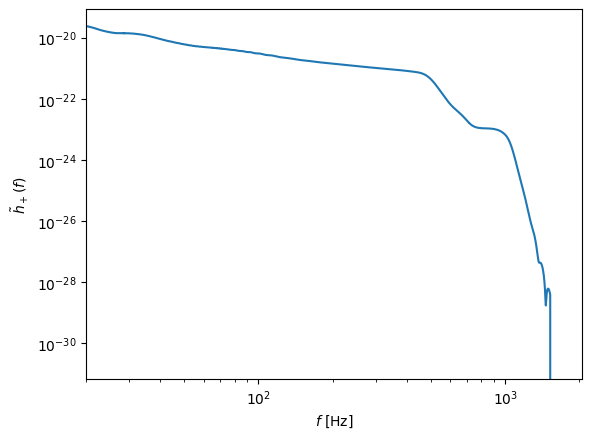

In [ ]:
plt.loglog(h['fd-ps']['freq'], np.abs(h['fd-ps']['plus']))
plt.xlim(20., 2048.)
plt.xlabel(r'$f$ [Hz]')
plt.ylabel(r'$\tilde{h}_+(f)$')
plt.show()

### Quiz:

* Which different parameters are used to generate a frequency domain waveform compared to a time domain waveform?

### Exercise:

* Generate and plot a frequency domain waveform for a non-equal mass and inclined precessing system using `IMRPhenomXPHM`.